In [1]:
import pandas as pd

DATA

In [2]:
data = {
    'MarketTrend': ['Up', 'Up', 'Down', 'Up', 'Down', 'Down', 'Up', 'Up', 'Down', 'Up', 'Down', 'Up', 'Down', 'Up'],
    'Volume': ['High', 'Low', 'High', 'High', 'Low', 'High', 'Low', 'High', 'High', 'Low', 'Low', 'High', 'High', 'Low'],
    'News': ['Positive', 'Positive', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
    'RSI': ['High', 'Medium', 'Low', 'High', 'Low', 'Medium', 'Medium', 'High', 'Low', 'Medium', 'Low', 'High', 'Medium', 'High'],
    'Decision': ['Buy', 'Buy', 'Sell', 'Buy', 'Sell', 'Sell', 'Buy', 'Sell', 'Sell', 'Buy', 'Sell', 'Buy', 'Sell', 'Buy']
}
df = pd.DataFrame(data)
df

,MarketTrend,Volume,News,RSI,Decision
0,Up,High,Positive,High,Buy
1,Up,Low,Positive,Medium,Buy
2,Down,High,Negative,Low,Sell
3,Up,High,Positive,High,Buy
4,Down,Low,Negative,Low,Sell
5,Down,High,Negative,Medium,Sell
6,Up,Low,Positive,Medium,Buy
7,Up,High,Negative,High,Sell
8,Down,High,Negative,Low,Sell
9,Up,Low,Positive,Medium,Buy


**GINI IMPURITY** FUNCTION 1

In [3]:
def gini_impurity(target_series):

    counts = target_series.value_counts()
    total = len(target_series)

    if total == 0:
        return 0.0

    gini = 1.0
    for count in counts:
        proportion = count / total
        gini -= proportion**2
    return gini

print("Defined function: calculate_gini_impurity")

Defined function: calculate_gini_impurity


**now calculating gini**

In [4]:
initial_gini = gini_impurity(df['Decision'])
print(f"gini_impurity count : {initial_gini:.3f}")

gini_impurity count : 0.500


INFORMATION GAIN :- function 2

In [14]:
def calculate_information_gain(df, feature_name, target_name, gini_parent):

    weighted_gini_children = 0.0
    total_samples = len(df)


    for value in df[feature_name].unique():

        subset = df[df[feature_name] == value]
        gini_subset = gini_impurity(subset[target_name])
        weight_subset = len(subset) / total_samples
        weighted_gini_children += weight_subset * gini_subset

    information_gain = gini_parent - weighted_gini_children
    return information_gain

print("Defined function: calculate_information_gain")

Defined function: calculate_information_gain


now using information gain function

In [16]:
target_name = 'Decision'
features = [col for col in df.columns if col != target_name]

best_gain = -1
best_feature = None
best_split_value = None

print(f"\nCalculating information gain for each feature to find the best split (Root Node Gini: {initial_gini:.3f}):\n")

for feature in features:
    print(f"  Evaluating feature: '{feature}'")
    for value in df[feature].unique():
        current_gain = calculate_information_gain(df, feature, target_name, initial_gini)
        print(f"    Potential Split on '{feature}' with values: {df[feature].unique()} -> Information Gain: {current_gain:.3f}")


        if current_gain > best_gain:
            best_gain = current_gain
            best_feature = feature


print(f"\nOptimal first split found:")
print(f"  Best Feature: '{best_feature}'")
print(f"  Information Gain: {best_gain:.3f}")
print(f"This indicates '{best_feature}' is the optimal first split for the decision tree based on Gini impurity, as it yields the highest information gain.")


Calculating information gain for each feature to find the best split (Root Node Gini: 0.500):

  Evaluating feature: 'MarketTrend'
    Potential Split on 'MarketTrend' with values: ['Up' 'Down'] -> Information Gain: 0.375
    Potential Split on 'MarketTrend' with values: ['Up' 'Down'] -> Information Gain: 0.375
  Evaluating feature: 'Volume'
    Potential Split on 'Volume' with values: ['High' 'Low'] -> Information Gain: 0.042
    Potential Split on 'Volume' with values: ['High' 'Low'] -> Information Gain: 0.042
  Evaluating feature: 'News'
    Potential Split on 'News' with values: ['Positive' 'Negative'] -> Information Gain: 0.500
    Potential Split on 'News' with values: ['Positive' 'Negative'] -> Information Gain: 0.500
  Evaluating feature: 'RSI'
    Potential Split on 'RSI' with values: ['High' 'Medium' 'Low'] -> Information Gain: 0.214
    Potential Split on 'RSI' with values: ['High' 'Medium' 'Low'] -> Information Gain: 0.214
    Potential Split on 'RSI' with values: ['High' 

**TREE GENERATION**

In [19]:
df_encoded = pd.get_dummies(df, columns=['MarketTrend', 'Volume', 'News', 'RSI'], drop_first=False)
print("DataFrame after :")
print(df_encoded)

DataFrame after :
   Decision  MarketTrend_Down  MarketTrend_Up  Volume_High  Volume_Low  \
0       Buy             False            True         True       False   
1       Buy             False            True        False        True   
2      Sell              True           False         True       False   
3       Buy             False            True         True       False   
4      Sell              True           False        False        True   
5      Sell              True           False         True       False   
6       Buy             False            True        False        True   
7      Sell             False            True         True       False   
8      Sell              True           False         True       False   
9       Buy             False            True        False        True   
10     Sell              True           False        False        True   
11      Buy             False            True         True       False   
12     Sell         

In [21]:
X = df_encoded.drop('Decision', axis=1)
y = df_encoded['Decision']

print("Features (X) head:")
print(X)
print("\nTarget (y) head:")
print(y)

Features (X) head:
    MarketTrend_Down  MarketTrend_Up  Volume_High  Volume_Low  News_Negative  \
0              False            True         True       False          False   
1              False            True        False        True          False   
2               True           False         True       False           True   
3              False            True         True       False          False   
4               True           False        False        True           True   
5               True           False         True       False           True   
6              False            True        False        True          False   
7              False            True         True       False           True   
8               True           False         True       False           True   
9              False            True        False        True          False   
10              True           False        False        True           True   
11             False 

***visulize Tree***

In [26]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42, criterion='gini')
dtree.fit(X, y)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


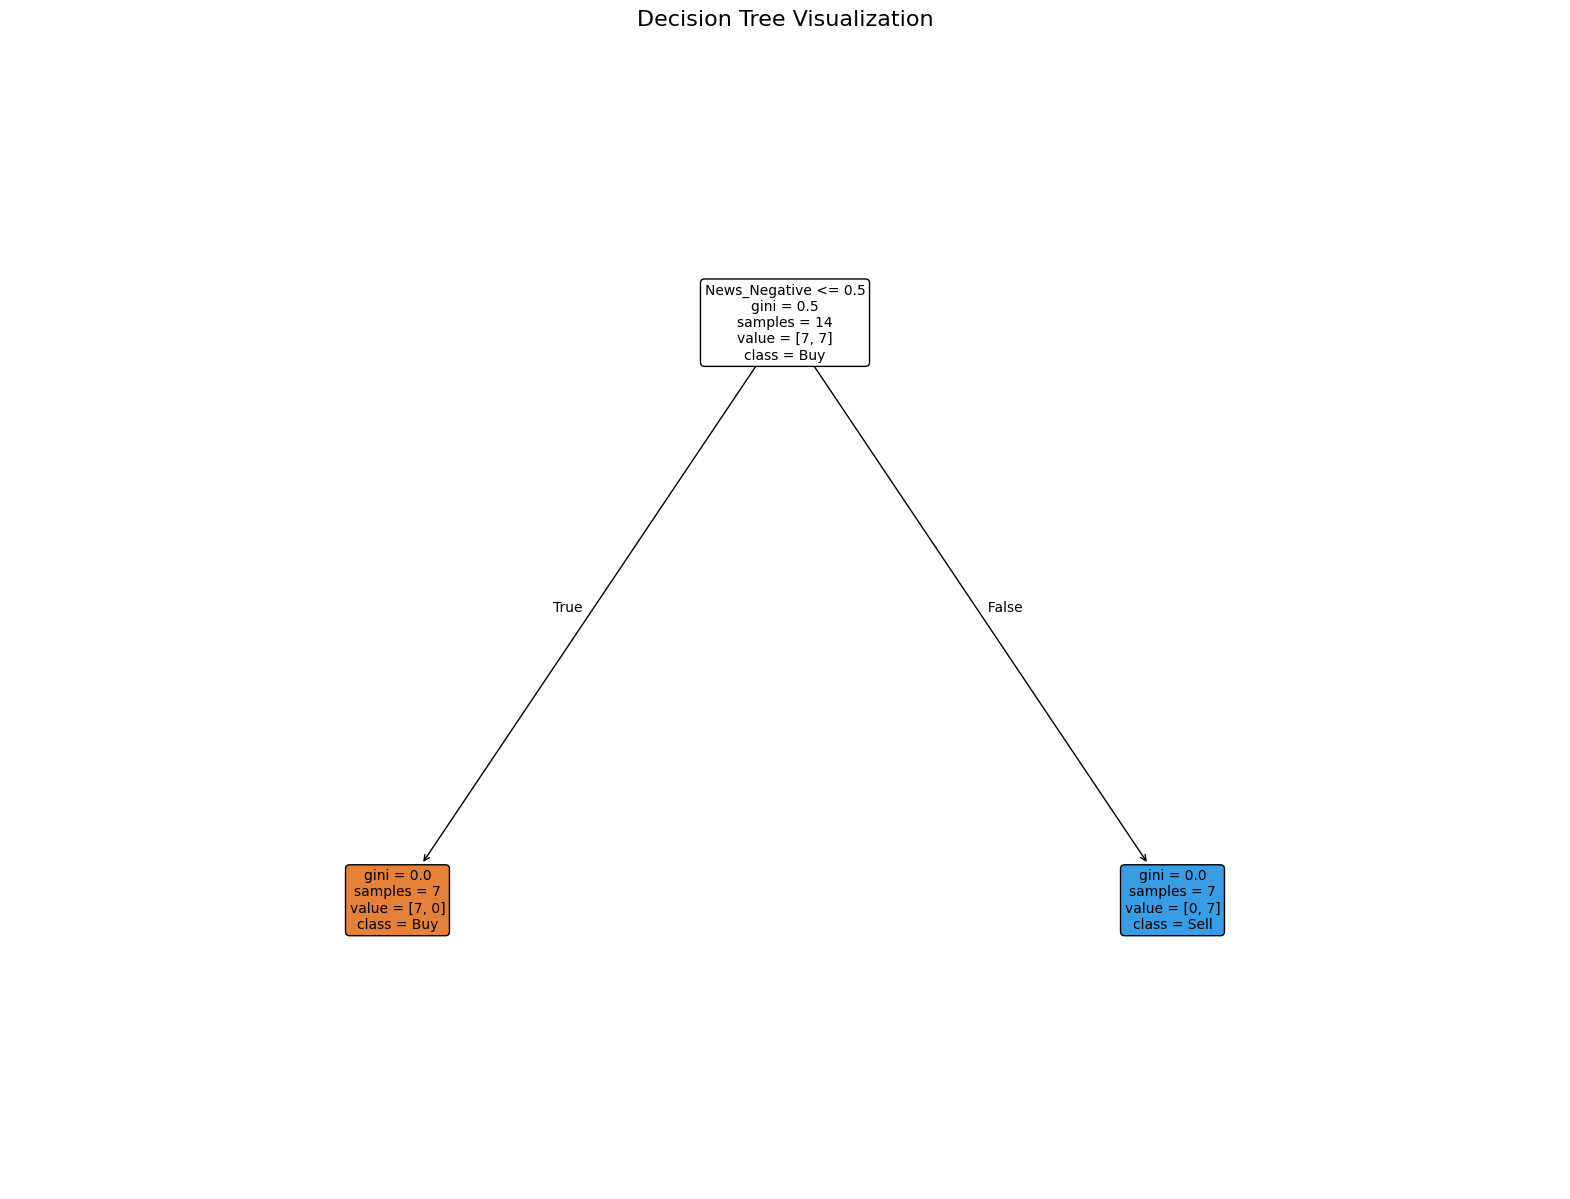

Decision Tree visualized successfully.


In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 15))


plot_tree(dtree,
          feature_names=X.columns.tolist(),
          class_names=y.unique().tolist(),
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree Visualization', fontsize=16)
plt.show()

print("Decision Tree visualized successfully.")